In [ ]:
import os
import time
import sys
import pickle
from pathlib import Path
import pandas as pd
import argparse
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
# Add parent directory to sys.path
parent_dir = Path('utils_model_training.py').resolve().parent.parent
sys.path.append(str(parent_dir))

from utils_model_training import preprocessing_train, preprocessing_test, get_optimal_threshold, merge_and_clean, get_multiclass_results, get_stats_with_ci, generate_features_table

In [ ]:
### SETTINGS
# is_by_patient -> splits dataset by patientID first if True
# is_single_slice -> takes only one slice per patient for training or testing if True
is_bypatient = bool(False)
is_single_slice = bool(True)

# True -> RFECV, False -> RFE
is_optimal_features = bool(False)

# datasets 
clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
features_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/full_radiomics_per_slice.csv'))
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')

#outcome_stage = 'Histology'
outcome_stage = 'Overall.Stage'

#generating per-patient statistics

features_df = features_df.drop(columns=['slice_no'])
features_df = generate_features_table(features_df)

# merging and cleaning datasets
mapping = {'I': 0, 'II': 1, 'IIIa':2, 'IIIb':2}
#mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }
merged_df = merge_and_clean(features_df, clinical_df, mapping, outcome_stage)


# only extract one slice per patient ID
if is_single_slice == True:
    merged_df = merged_df.groupby(by='PatientID').sample(n=1, random_state=240).reset_index(drop=True)


if is_bypatient == True:
    # test train split by patient ID
    temp_df = clinical_df.dropna(subset=[outcome_stage])
    X = temp_df['PatientID']
    y = temp_df[outcome_stage]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=240, stratify=y)

    # save patient IDs for deep learning test train split later
    train_labels = X_train.unique()
    test_labels = X_test.unique()


    # create test train split dfs for training
    X_train = merged_df.loc[merged_df['PatientID'].isin(train_labels)]
    y_train = X_train[outcome_stage]
    X_test = merged_df.loc[merged_df['PatientID'].isin(test_labels)]
    y_test = X_test[outcome_stage]

    X_train = X_train.drop(columns=['PatientID', outcome_stage])#, 'slice_no'])
    X_test = X_test.drop(columns=['PatientID', outcome_stage])#, 'slice_no'])

else:
    #test train split NOT by patient ID, but by slice

    X = merged_df.drop(columns=['PatientID', outcome_stage])
    y = merged_df[outcome_stage]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=310, stratify=y)

print(f'Number of outcome classes: {len(y_train.unique())}')





# preprocess training dataset first 

mean_std, selector, to_drop, decor_dataset_train = preprocessing_train(X_train)
decor_dataset_test = preprocessing_test(X_test, mean_std, selector, to_drop)
print('features processed. New shape of training dataset:', decor_dataset_train.shape, 'before:', X_train.shape)

if len(y_train.unique()) > 2:
    objective = 'multi:softprob'
else:
    objective = 'binary:logistic'

#model definition
model = xgb.XGBClassifier(enable_categorical=True, colsample_bytree=1, eta=0.01, max_depth=4,
                            objective=objective, eval_metric='logloss', nthread=8, #'multi:softprob'
                            gamma=0.5, seed=240)

#measuring time to train one model
#start_model1 = time.time()
#model.fit(X_train, y_train)
#T_single_model1 = time.time() - start_model1

# recursive feature elimination with cross validation:
min_features_to_select = 10

T_single_rfecv = None
T_single_rfe = None

if len(y_train.unique()) > 2:
    scoring = 'roc_auc_ovr_weighted'
else:
    scoring = 'roc_auc'

if is_optimal_features == True:



    print('Performing RFECV')
    rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(10),
                scoring=scoring,
                min_features_to_select=min_features_to_select)

    start_rfecv = time.time()
    rfecv.fit(decor_dataset_train, y_train)
    T_single_rfecv = time.time() - start_rfecv
    support = rfecv.support_

    fig, ax = plt.subplots(figsize=(8, 6))
    no_features = rfecv.cv_results_['n_features']

    # plot line for each fold
    for k in range(10):
        scores = rfecv.cv_results_[f"split{k}_test_score"]
        ax.plot(no_features, scores, alpha=0.5, label=f"Fold {k}")

    # mean score
    mean_scores = rfecv.cv_results_['mean_test_score']
    ax.plot(no_features, mean_scores, color='black', linewidth=2, label='Mean')

    ax.set(xlabel='no. of features', ylabel='roc_auc')
    ax.set_title('Results of RFECV cross validation')
    ax.legend()
    fig.savefig(path_to_save + r'/RFECV_results.png')


#todo: print out cross validation outcome

else:
    print('Performing RFE')
    rfe = RFE(estimator=model, n_features_to_select=15)
    start_rfe = time.time()
    rfe.fit(decor_dataset_train, y_train)
    T_single_rfe = time.time() - start_rfe
    support = rfe.support_


filtered_col = np.extract(support, np.array(decor_dataset_train.columns))
reduced_features_train_set = decor_dataset_train[filtered_col]
reduced_features_test_set = decor_dataset_test[filtered_col]


# parameters for XGBoost model

param_test_xgb = {
        'max_depth': range(2, 6, 1),
        'min_child_weight': [1], #range(1, 6, 2)
        'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5], #was originally [i * 0.1 for i in range(1, 10)]
        'n_estimators': [200, 300, 400, 500], #int(x) for x in np.linspace(start=200, stop=400, num=100)
    }

kfold = StratifiedKFold(n_splits=10, random_state=240, shuffle=True) #increase this back to 10 ?
gsearch = GridSearchCV(model, param_grid=param_test_xgb, scoring=scoring, n_jobs=4, cv=kfold, verbose=1) #'roc_auc_ovr_weighted'

#measure time for gsearch
start_gsearch = time.time()
gsearch.fit(reduced_features_train_set, y_train)
T_single_gsearch = time.time() - start_gsearch


# predictions
best_estimator = gsearch.best_estimator_
proba_train = best_estimator.predict_proba(reduced_features_train_set)
proba_test = best_estimator.predict_proba(reduced_features_test_set)

/home/coder/project/xAI-in-NSCLC/utils_model_training.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df = full_df.reset_index()


Number of outcome classes: 3
Original size: 2640


KeyboardInterrupt: 

In [ ]:
print(proba_train[:5])

optimal_threshold = get_optimal_threshold(y_train, proba_train[:, 1], pos_label=1)

if len(y_train.unique()) > 2:

    results_train = get_multiclass_results(y_train, proba_train, "train")
    results_test = get_multiclass_results(y_test, proba_test, "test")

    results_overall = pd.concat([results_train, results_test])

else:
    df_distributions_train, df_results_train = get_stats_with_ci(y_train, proba_train[:, 1], 'train', optimal_threshold, nsamples=2000)
    df_distributions_test, df_results_test = get_stats_with_ci(y_test, proba_test[:, 1], 'test', optimal_threshold, nsamples=2000)

    results_overall = pd.concat([df_results_train, df_results_test])


[[0.25036216 0.74963784]
 [0.14703822 0.8529618 ]
 [0.23316103 0.76683897]
 [0.09034318 0.9096568 ]
 [0.7711861  0.2288139 ]]


/home/coder/.local/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/coder/.local/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/coder/.local/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/coder/.local/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/coder/.local/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/coder/.lo

In [ ]:
print('\nOUTCOME DISTRIBUTION & PERFORMANCE ACROSS TRAIN/TEST: --------------------------------')

print(f'\ny_train: {y_train.value_counts()/len(y_train)} N = {len(y_train)}')
print(f'\ny_test: {y_test.value_counts()/len(y_test)} N = {len(y_test)}')
print('\nModel results:')
print(results_overall)

print('\nSELECTED FEATURES: -----------------------------------------------------------------')

print('\nSelected features: ' + str(filtered_col))
print(f'\nSelected {len(filtered_col)} out of {decor_dataset_test.shape[1]} features')

print('\nFEATURE SELECTION AND TRAINING TIMES: ------------------------------------------------')

#print(f'Training of singular xgboost model took {T_single_model1:.2f} seconds')
if T_single_rfecv is not None:
    print(f'\nRecursive feature elimination with cross validation took {T_single_rfecv / 60:.2f} minutes')
if T_single_rfe is not None:
    print(f'\nRecursive feature elimination took {T_single_rfe/ 60:.2f} minutes')

print(f'Gridsearch took {T_single_gsearch/ 60:.2f} minutes')


OUTCOME DISTRIBUTION & PERFORMANCE ACROSS TRAIN/TEST: --------------------------------

y_train: Overall.Stage
1    0.628571
0    0.371429
Name: count, dtype: float64 N = 35

y_test: Overall.Stage
1    0.666667
0    0.333333
Name: count, dtype: float64 N = 15

Model results:
                       auc                                accuracy  \
train  1.00 CI [1.00,1.00]     34/   35 (   97 % )  CI [0.91,1.00]   
test     0.26 CI [nan,nan]      3/   15 (   20 % )  CI [0.00,0.40]   

                                    precision  \
train     21/   21 (  100 % )  CI [1.00,1.00]   
test       1/    4 (   25 % )  CI [0.00,1.00]   

                                  specificity  \
train     13/   13 (  100 % )  CI [1.00,1.00]   
test       2/    5 (   40 % )  CI [0.00,1.00]   

                                       recall  \
train     21/   22 (   95 % )  CI [0.85,1.00]   
test       1/   10 (   10 % )  CI [0.00,0.33]   

                                     f1 score  
train      0/    0 (

In [ ]:
import shap

/home/coder/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X_process = pd.concat([reduced_features_train_set, reduced_features_test_set])
print(X_process.shape)
X_process.head()

(50, 15)


,original_firstorder_Minimum_mean,original_glcm_ClusterProminence_mean,original_ngtdm_Contrast_mean,original_glcm_JointEntropy_stdev,log-sigma-0-1-mm-3D_firstorder_Mean_stdev,log-sigma-0-1-mm-3D_glcm_JointAverage_stdev,wavelet-H_glcm_MCC_stdev,original_shape2D_Elongation_max,original_firstorder_Skewness_max,log-sigma-0-7-mm-3D_glcm_ClusterShade_max,wavelet-H_glcm_ClusterShade_max,wavelet-H_glcm_Correlation_max,log-sigma-0-1-mm-3D_firstorder_Skewness_min,log-sigma-1-0-mm-3D_glcm_Correlation_min,wavelet-H_glcm_Correlation_min
18,-1.934288,1.766265,-0.214478,-0.413268,-0.642333,-0.024383,-0.758829,-1.051930,0.514575,-0.026133,0.211732,-1.258256,0.257895,-0.763735,0.005860
44,-0.048596,-0.407520,0.261530,0.573464,0.789535,-0.260671,0.975257,1.112800,0.028009,-0.526030,-0.282430,0.671498,0.392390,-1.804646,0.168891
6,1.110723,-0.936066,-0.017701,0.990653,0.125316,-1.177458,-0.084654,1.005148,0.022364,-0.113010,-0.650928,0.720609,0.262874,0.436286,1.876974
39,0.749599,-0.837167,-0.356514,0.491008,0.190596,1.789337,1.096275,1.033966,0.027305,-0.644986,-0.638811,-0.080476,-3.013921,-0.132845,-0.860404
43,-0.075639,-0.429208,-0.473824,-1.198444,-0.822862,-0.436817,0.037161,-0.018053,0.202255,-0.458021,-0.152630,1.074733,0.443082,0.408587,0.603488


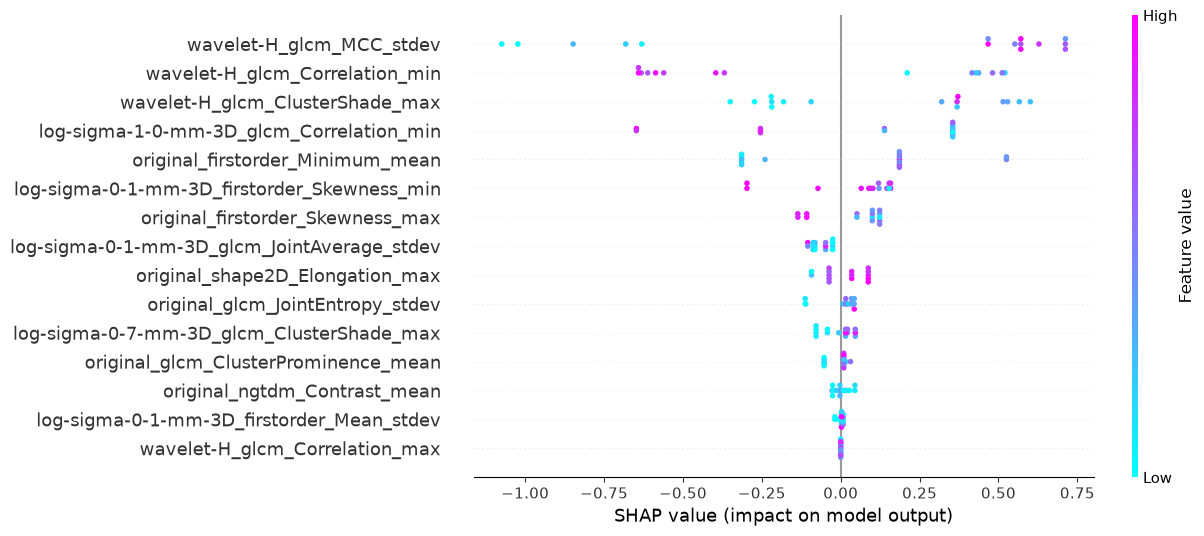

In [ ]:
explainer = shap.TreeExplainer(best_estimator)
shap_values = explainer(reduced_features_test_set)
fig = shap.plots.beeswarm(shap_values, max_display=reduced_features_test_set.shape[1], plot_size=[10, 6], color=plt.get_cmap('cool'), show=False)
plt.savefig('Model_shap.png', bbox_inches='tight')

In [9]:
import random

In [ ]:
neg = y_test.loc[y_test == 0]
pos = y_test.loc[y_test == 1]

neg_list = neg.index
pos_list = pos.index

neg_idx = random.choice(neg_list)
pos_idx = random.choice(pos_list)
# Source - https://stackoverflow.com/a/28837788
# Posted by TomAugspurger, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-15, License - CC BY-SA 3.0
neg_idx = y_test.index.get_loc(neg_idx)
pos_idx = y_test.index.get_loc(pos_idx)


#negative plot
fig, ax = plt.subplots()

shap.plots.waterfall(shap_values[neg_idx], max_display=10, show=False)
fig.set_size_inches(10, 6)
fig = plt.gcf()
fig.tight_layout()


fig.savefig(str(output_dir) + '/SHAP-figures/Positive_patient_shap.png', bbox_inches='tight')
plt.close(fig)


In [ ]:
output_dir = os.path.expanduser('~/project/xAI-in-NSCLC')

In [ ]:
fig, ax = plt.subplots()

shap.plots.waterfall(shap_values[pos_idx], max_display=10, show=False) #reduced_features_test_set.shape[1]
fig.set_size_inches(10, 6)
fig = plt.gcf()
fig.tight_layout()

fig.savefig(str(output_dir) + '/SHAP-figures/Positive_patient_shap.png', bbox_inches='tight')
plt.close(fig)

In [6]:
results_overall

,auc,accuracy,precision,specificity,recall,f1 score
train,"0.95 CI [0.93,0.98]","264/ 289 ( 91 % ) CI [0.88,0.94]","180/ 188 ( 95 % ) CI [0.93,0.98]","84/ 92 ( 91 % ) CI [0.85,0.97]","180/ 197 ( 91 % ) CI [0.87,0.95]","0/ 0 ( 93 % ) CI [0.91,0.96]"
test,"0.63 CI [0.53,0.73]","80/ 125 ( 64 % ) CI [0.55,0.72]","62/ 84 ( 73 % ) CI [0.64,0.83]","18/ 40 ( 45 % ) CI [0.30,0.61]","62/ 85 ( 72 % ) CI [0.63,0.82]","0/ 0 ( 73 % ) CI [0.66,0.80]"


In [38]:
# imports
import os
import time
import pickle
import pandas as pd
import argparse
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

#from utils_pyradiomics import preprocessing_train, preprocessing_test, get_optimal_threshold
#from preprocessing.radiomics_extraction import initialize_feature_extractor,generate_features_table
#from radiomics_pipeline.utils import preprocessing_train, preprocessing_test

In [39]:
# merge outcome with pyradiomics feature table

clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
features_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/full_radiomics_per_slice.csv'))
print(clinical_df.shape, features_df.shape)

(422, 10) (7223, 662)


In [40]:
features_df = features_df.drop(columns='slice_no')

def generate_features_table(df):
    means = df.groupby(by='PatientID').mean()
    means.columns = means.columns + '_mean'

    stdevs = df.groupby(by='PatientID').std()
    stdevs.columns = stdevs.columns +'_stdev'

    maxs = features_df.groupby(by='PatientID').max()
    maxs.columns = maxs.columns +'_max'

    mins = features_df.groupby(by='PatientID').min()
    mins.columns = mins.columns +'_min'

    full_df = pd.concat([means, stdevs, maxs, mins], axis=1, sort=True, ignore_index=False)
    full_df = full_df.reset_index()
    return full_df

In [41]:
full_df = generate_features_table(features_df)
full_df.head()

,PatientID,original_shape2D_Elongation_mean,original_shape2D_MajorAxisLength_mean,original_shape2D_MaximumDiameter_mean,original_shape2D_MeshSurface_mean,original_shape2D_MinorAxisLength_mean,original_shape2D_Perimeter_mean,original_shape2D_PerimeterSurfaceRatio_mean,original_shape2D_PixelSurface_mean,original_shape2D_Sphericity_mean,...,wavelet-L_gldm_LargeDependenceLowGrayLevelEmphasis_min,wavelet-L_gldm_LowGrayLevelEmphasis_min,wavelet-L_gldm_SmallDependenceEmphasis_min,wavelet-L_gldm_SmallDependenceHighGrayLevelEmphasis_min,wavelet-L_gldm_SmallDependenceLowGrayLevelEmphasis_min,wavelet-L_ngtdm_Busyness_min,wavelet-L_ngtdm_Coarseness_min,wavelet-L_ngtdm_Complexity_min,wavelet-L_ngtdm_Contrast_min,wavelet-L_ngtdm_Strength_min
0,LUNG1-001,0.664286,66.318649,68.514914,2480.847495,43.519162,207.012394,0.145422,2481.324332,0.793277,...,0.000264,0.000262,0.927241,69060.995000,0.000262,0.000347,0.003598,200351.437304,0.547164,498.141292
1,LUNG1-002,0.860299,81.031923,85.017333,4608.098885,70.642490,264.917223,0.070322,4608.576150,0.880503,...,0.000157,0.000156,0.908154,35773.452061,0.000155,0.000499,0.002557,32048.564397,0.254853,253.584453
2,LUNG1-003,0.613095,38.877481,38.730940,682.235566,22.650544,107.239197,0.169451,682.712830,0.855667,...,0.000883,0.000882,0.936382,51392.093373,0.000882,0.000381,0.012230,259407.138260,2.558369,936.778391
3,LUNG1-004,0.633445,40.287161,41.691337,781.562593,24.592421,113.048058,0.169551,782.039430,0.855893,...,0.000670,0.000668,0.929932,1548.257282,0.000668,0.000371,0.010234,5058.895219,0.811812,50.229547
4,LUNG1-005,0.600210,52.433795,54.738602,1159.911823,30.621580,153.134561,0.137649,1160.389088,0.795653,...,0.000500,0.000498,0.928635,3705.550671,0.000497,0.000381,0.007459,15300.018138,0.242677,44.934138


In [36]:
features_df = features_df.drop(columns='slice_no')

means = features_df.groupby(by='PatientID').mean()
means.columns = means.columns + '_mean'

stdevs = features_df.groupby(by='PatientID').std()
stdevs.columns = stdevs.columns +'_stdev'

maxs = features_df.groupby(by='PatientID').max()
maxs.columns = maxs.columns +'_max'

mins = features_df.groupby(by='PatientID').min()
mins.columns = mins.columns +'_min'

full_df = pd.concat([means, stdevs, maxs, mins], axis=1, sort=True, ignore_index=False)
full_df = full_df.reset_index()
display(full_df.head())

,PatientID,original_shape2D_Elongation_mean,original_shape2D_MajorAxisLength_mean,original_shape2D_MaximumDiameter_mean,original_shape2D_MeshSurface_mean,original_shape2D_MinorAxisLength_mean,original_shape2D_Perimeter_mean,original_shape2D_PerimeterSurfaceRatio_mean,original_shape2D_PixelSurface_mean,original_shape2D_Sphericity_mean,...,wavelet-L_gldm_LargeDependenceLowGrayLevelEmphasis_min,wavelet-L_gldm_LowGrayLevelEmphasis_min,wavelet-L_gldm_SmallDependenceEmphasis_min,wavelet-L_gldm_SmallDependenceHighGrayLevelEmphasis_min,wavelet-L_gldm_SmallDependenceLowGrayLevelEmphasis_min,wavelet-L_ngtdm_Busyness_min,wavelet-L_ngtdm_Coarseness_min,wavelet-L_ngtdm_Complexity_min,wavelet-L_ngtdm_Contrast_min,wavelet-L_ngtdm_Strength_min
0,LUNG1-001,0.664286,66.318649,68.514914,2480.847495,43.519162,207.012394,0.145422,2481.324332,0.793277,...,0.000264,0.000262,0.927241,69060.995000,0.000262,0.000347,0.003598,200351.437304,0.547164,498.141292
1,LUNG1-002,0.860299,81.031923,85.017333,4608.098885,70.642490,264.917223,0.070322,4608.576150,0.880503,...,0.000157,0.000156,0.908154,35773.452061,0.000155,0.000499,0.002557,32048.564397,0.254853,253.584453
2,LUNG1-003,0.613095,38.877481,38.730940,682.235566,22.650544,107.239197,0.169451,682.712830,0.855667,...,0.000883,0.000882,0.936382,51392.093373,0.000882,0.000381,0.012230,259407.138260,2.558369,936.778391
3,LUNG1-004,0.633445,40.287161,41.691337,781.562593,24.592421,113.048058,0.169551,782.039430,0.855893,...,0.000670,0.000668,0.929932,1548.257282,0.000668,0.000371,0.010234,5058.895219,0.811812,50.229547
4,LUNG1-005,0.600210,52.433795,54.738602,1159.911823,30.621580,153.134561,0.137649,1160.389088,0.795653,...,0.000500,0.000498,0.928635,3705.550671,0.000497,0.000381,0.007459,15300.018138,0.242677,44.934138


In [17]:
merged_df = pd.merge(features_df, clinical_df[['PatientID', 'Histology']], on='PatientID', how='left')
merged_df = merged_df.sort_values(by=['PatientID'], ascending=True)

In [6]:
new_merged_df = pd.DataFrame()

# Group by patient and compute statistics
grouped = merged_df.groupby("PatientID")

# Compute mean, std, min, max for all variables except excluded ones
stats_df = grouped[
    merged_df.drop(columns=['Histology', 'PatientID', 'slice_no']).columns
].agg(['mean', 'std', 'min', 'max'])

# Flatten the MultiIndex column names
stats_df.columns = ['_'.join(col) for col in stats_df.columns]

# Reset index so PatientID becomes a column
new_merged_df = stats_df.reset_index()

In [9]:

merged_df = new_merged_df.merge(merged_df[['Histology', 'PatientID']], on='PatientID')

In [ ]:
merged_d

In [ ]:
merged_df['Overall.Stage'].isna().sum()

np.int64(5)

In [7]:
merged_df = new_merged_df

In [8]:
merged_df_clean = merged_df.dropna(subset=['Histology'])

KeyError: ['Histology']

In [6]:
merged_df_clean['Overall.Stage'].unique()

array(['IIIb', 'I', 'II', 'IIIa'], dtype=object)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


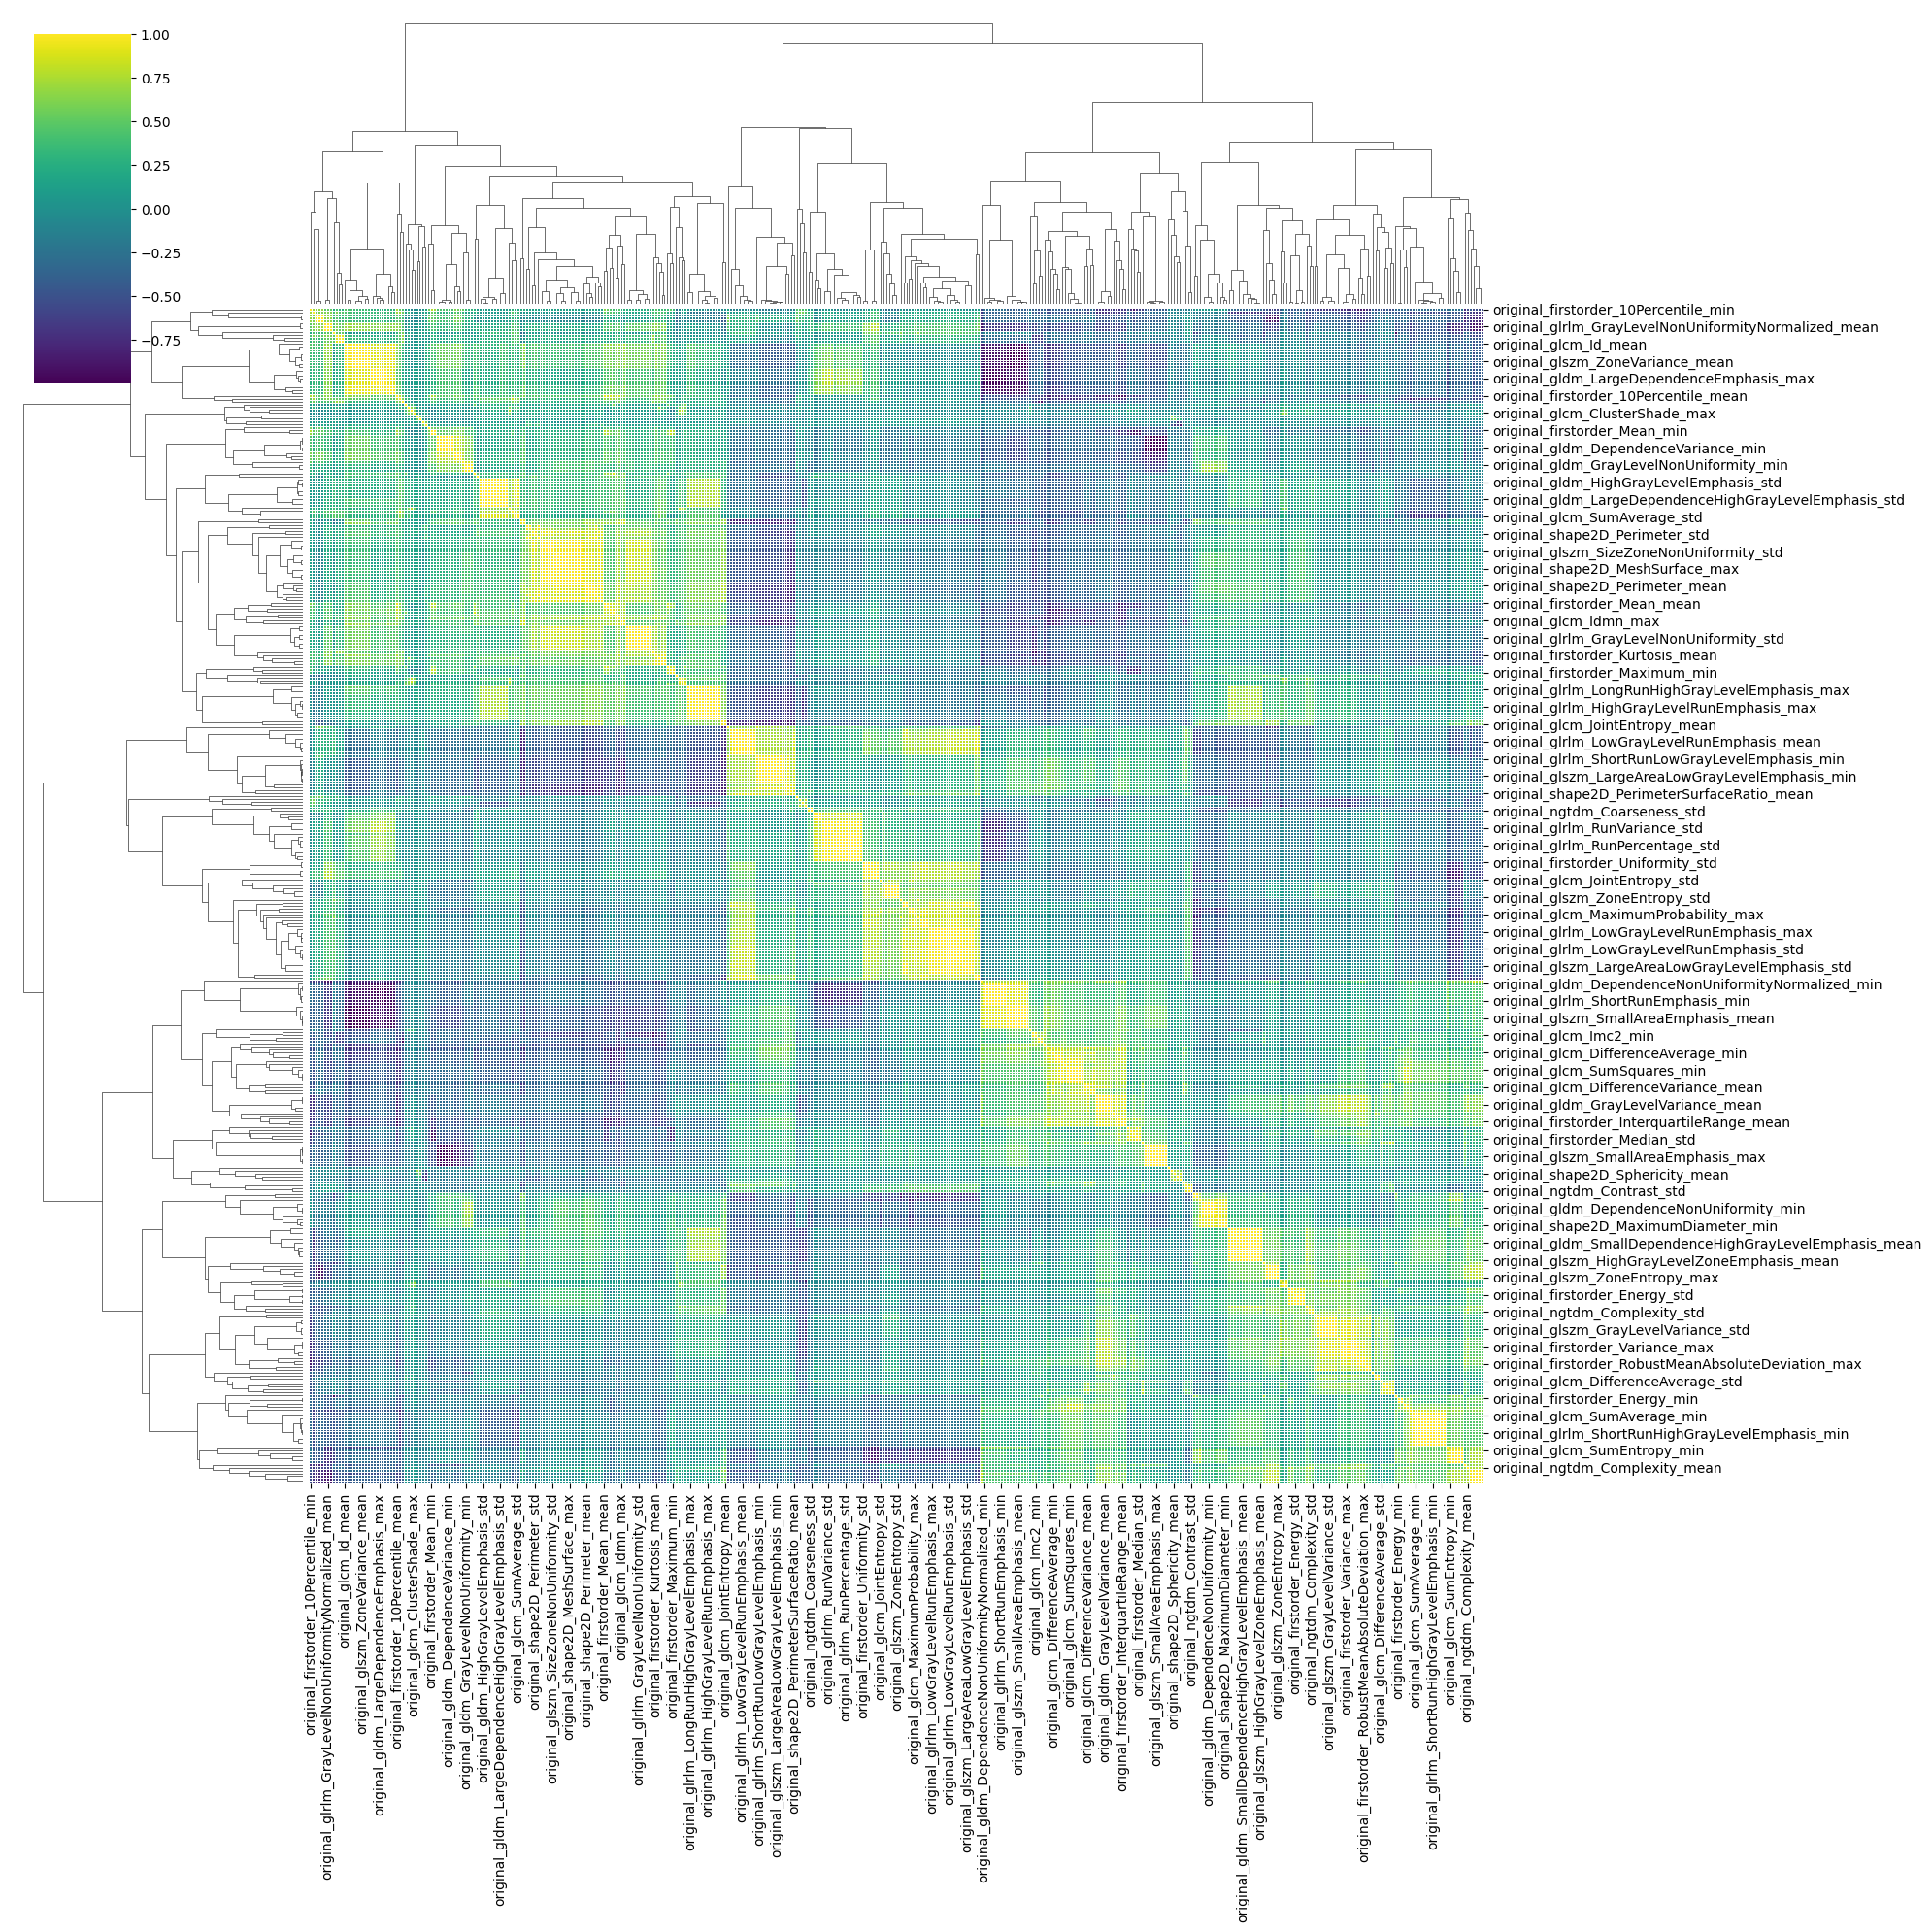

In [11]:
#df = merged_df_clean.drop(labels=['slice_no', 'Histology'], axis=1) # 'PatientID'
df = merged_df
d_per_pat = df.groupby("PatientID").sample(n=1, random_state=42).reset_index(drop=True)
d_per_pat.drop(labels='PatientID', axis=1)

feature_names = sorted(filter ( lambda k: k.startswith("original_"), d_per_pat.columns))
#make dataframe with features
d = d_per_pat.loc[:,feature_names]


# Choose a subset of features for clustering
dd = d.iloc[:,:]

pp = sns.clustermap(dd.corr(),cmap='viridis', linewidths=.5, figsize=(20,20))
_ = plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)

#plt.show()

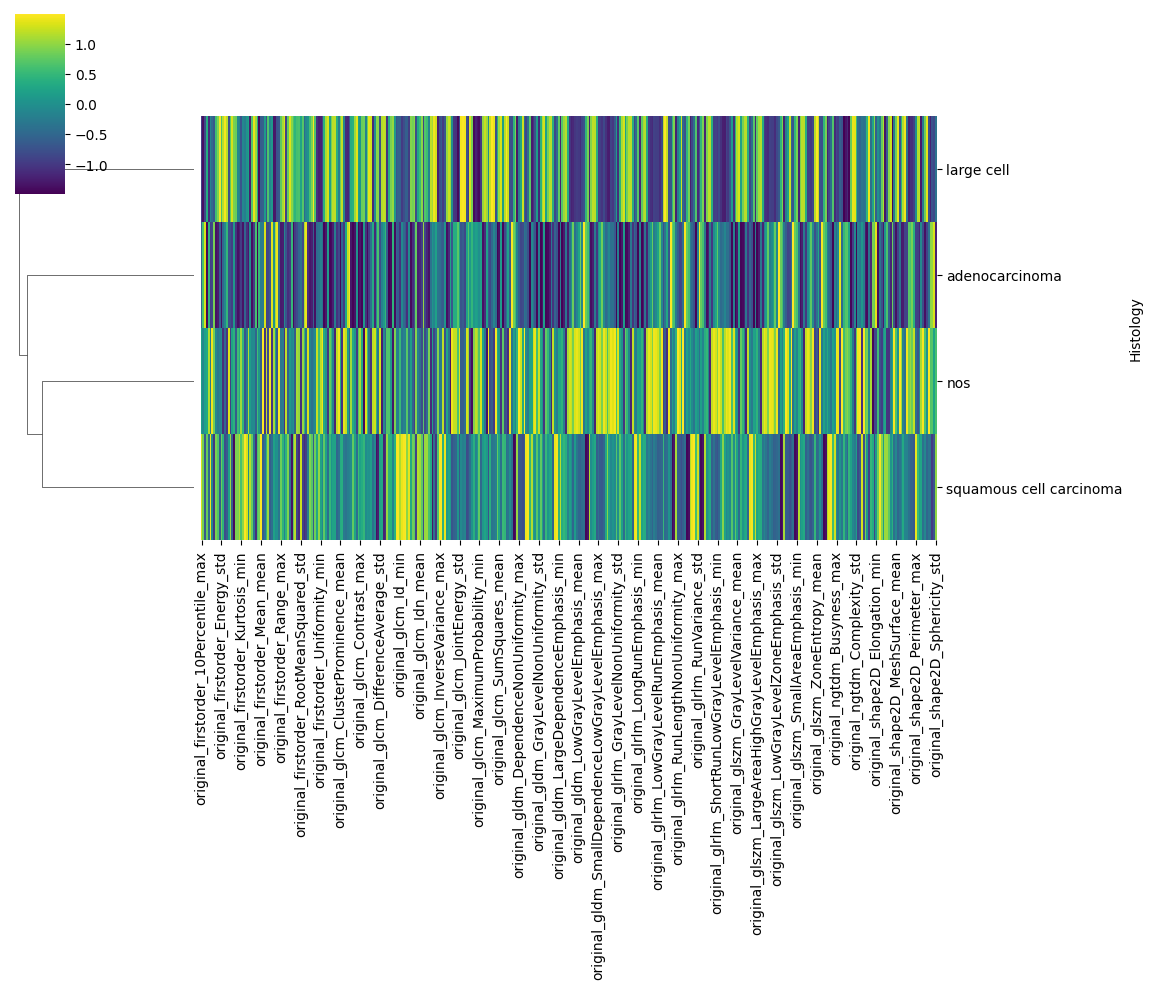

In [24]:
#Note that this view removes variables that have a z-score below 1, and are thereofre not statistically significant. 

#df = merged_df_clean.drop(labels=['PatientID', 'slice_no'], axis=1) # 'PatientID'
df = merged_df
df = df.merge(clinical_df[['Histology', 'PatientID']], on='PatientID')
df = df.drop(columns='PatientID')
d_per_his = df.groupby("Histology").mean()

feature_names = sorted(filter ( lambda k: k.startswith("original_"), d_per_his.columns))
#make dataframe with features
d = d_per_his.loc[:,feature_names]
dd = d.iloc[:,:]

pp = sns.clustermap(dd, cmap='viridis', col_cluster=False, metric='euclidean', z_score=1)
_ = plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)
plt.show()

In [7]:
merged_df = merged_df.dropna(subset=['Overall.Stage'])
merged_df['Overall.Stage'].isna().sum()

np.int64(0)

In [ ]:
#['IIIb', 'I', 'II', 'IIIa', nan]
mapping = {'I': 0, 'II': 1, 'IIIa':2, 'IIIb':3}

In [ ]:
#mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }
merged_df_clean['Histology'] = merged_df_clean['Histology'].map(mapping)
merged_df_clean['Histology'].unique()

/tmp/ipykernel_4025981/2304721031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['Histology'] = merged_df_clean['Histology'].map(mapping)


array([2, 1, 0, 3])

In [7]:
# run this cell if you want per pattient training
merged_df_clean = merged_df_clean.groupby(by='PatientID').sample(n=1, random_state=42).reset_index(drop=True)

In [7]:
#test train split NOT by patient ID, but by slice

X = merged_df_clean.drop(columns=['PatientID', 'Histology'])
y = merged_df_clean['Histology']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
# test train split by patient ID
temp_df = clinical_df.dropna(subset=['Histology'])
X = temp_df['PatientID']
y = temp_df['Histology']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=204, stratify=y)

#save patient IDs for deep learning test train split later
train_labels = X_train.unique()
test_labels = X_test.unique()

In [8]:
#create test train split dfs for training
X_train = merged_df_clean.loc[merged_df_clean['PatientID'].isin(train_labels)]
y_train = X_train['Histology']
X_test = merged_df_clean.loc[merged_df_clean['PatientID'].isin(test_labels)]
y_test = X_test['Histology']

X_train = X_train.drop(columns=['PatientID', 'Histology', 'slice_no'])
X_test = X_test.drop(columns=['PatientID', 'Histology', 'slice_no'])

In [9]:
# preprocess training dataset first 
mean_std, selector, to_drop, decor_dataset_train = preprocessing_train(X_train)
decor_dataset_test = preprocessing_test(X_test, mean_std, selector, to_drop)
print('features processed. New shape of training dataset:', decor_dataset_train.shape, 'before:', X_train.shape)

features processed. New shape of training dataset: (4735, 54) before: (4735, 660)


In [10]:
print(f'y_train: {y_train.value_counts()/len(y_train)} N = {len(y_train)}')
print(f'y_test: {y_test.value_counts()/len(y_test)} N = {len(y_test)}')

y_train: Histology
1    0.404857
2    0.297149
3    0.168321
0    0.129673
Name: count, dtype: float64 N = 4735
y_test: Histology
1    0.407164
2    0.312311
0    0.142785
3    0.137740
Name: count, dtype: float64 N = 1982


In [11]:
# model definition
model = xgb.XGBClassifier(enable_categorical=True, colsample_bytree=1, eta=0.01, max_depth=4,
                            objective='multi:softprob', eval_metric='logloss', nthread=8,
                            gamma=0.5, seed=204)

#note: can add 'device=cuda' to use GPU

#could you increase the number of threads for efficiency? To what number shoudl I increase it to?

#I think 32 is the limit for this environment.
# Hence using 8 threads + 4 jobs 

In [ ]:
# test to assume training time

#start = time.time()
#model.fit(X_train, y_train)
#T_single = time.time() - start
#print(T_single)


/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:54:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


11.648787260055542


In [11]:
#recursive feature elimination with no cross validation:

rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(decor_dataset_train, y_train)
support = rfe.support_


In [12]:
# recursive feature elimination with cross validation:
min_features_to_select = 1  # Minimum number of features to consider
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(10),
            scoring='roc_auc_ovr_weighted',
            min_features_to_select=min_features_to_select)
rfecv.fit(decor_dataset_train, y_train)
support = rfecv.support_

In [16]:
rfecv.cv_results_

{'mean_test_score': array([0.47468733, 0.51816635, 0.52481655, 0.53805158, 0.5401489 ,
        0.54869677, 0.55051178, 0.54321544, 0.54246379, 0.54002378,
        0.54115172, 0.5392394 , 0.53651323, 0.53421187, 0.53502868,
        0.53722342, 0.53791844, 0.53901816, 0.5391097 , 0.54416611,
        0.54445504, 0.54027468, 0.54076844, 0.53849439, 0.54223967,
        0.5437053 , 0.54530361, 0.54954866, 0.55158815, 0.55121588,
        0.55097901, 0.55127133, 0.55087712, 0.55255986, 0.55082751,
        0.55093118, 0.54999784, 0.55010173, 0.5512366 , 0.55057365,
        0.54935605, 0.54934303, 0.54908419, 0.54921189, 0.54912106,
        0.54895838, 0.55065557, 0.55389141, 0.55415757, 0.55410984,
        0.55376295, 0.55338735, 0.55338878, 0.55356579]),
 'std_test_score': array([0.06084175, 0.06962989, 0.07173524, 0.07019838, 0.07085368,
        0.07277279, 0.06923686, 0.0729915 , 0.07415291, 0.0761945 ,
        0.07419483, 0.07240106, 0.06580692, 0.06941352, 0.07123951,
        0.07064271, 0

In [23]:
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')

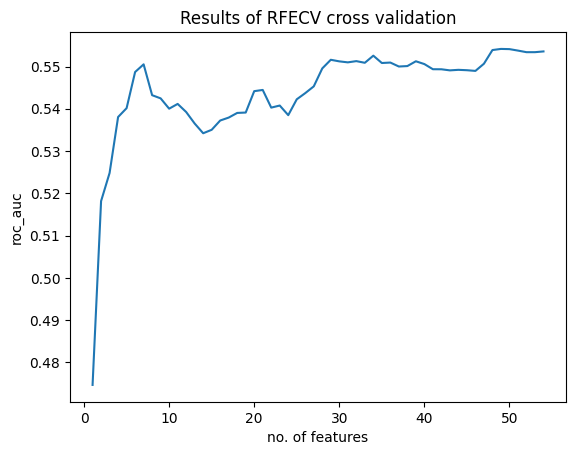

In [27]:
fig, ax = plt.subplots()
mean_scores = rfecv.cv_results_['mean_test_score']
no_features = rfecv.cv_results_['n_features']
ax.plot(no_features, mean_scores)
ax.set(xlabel='no. of features', ylabel='roc_auc')
ax.set_title('Results of RFECV cross validation')
fig.savefig(path_to_save + r'/RFECV_results.png')

In [12]:
filtered_col = np.extract(support, np.array(decor_dataset_train.columns))
reduced_features_train_set = decor_dataset_train[filtered_col]

In [13]:
filtered_col

array(['original_firstorder_10Percentile', 'original_firstorder_Maximum',
       'original_firstorder_Median', 'original_firstorder_Range',
       'original_glcm_ClusterShade',
       'log-sigma-0-1-mm-3D_firstorder_90Percentile',
       'log-sigma-0-1-mm-3D_firstorder_Energy',
       'log-sigma-0-1-mm-3D_glcm_Correlation',
       'wavelet-H_firstorder_Maximum', 'wavelet-H_glcm_Correlation'],
      dtype=object)

In [ ]:
#original cross validation search
param_test_xgb = {
        'max_depth': range(2, 4, 1),
        'min_child_weight': range(1, 6, 2),
        'gamma': [i * 0.1 for i in range(1, 10)], #was originally [i * 0.1 for i in range(1, 10)]
        'n_estimators': [int(x) for x in np.linspace(start=10, stop=1000, num=100)],
        'learning_rate': [10 ** (-i) for i in range(2, 3)] # was originally [10 ** (-i) for i in range(2, 7)]
    }

In [14]:
param_test_xgb = {
        'max_depth': range(3, 6, 1),
        'min_child_weight': [1],
        'gamma': [0, 0.2, 0.4], #was originally [i * 0.1 for i in range(1, 10)]
        'n_estimators': [200, 300, 400], #int(x) for x in np.linspace(start=200, stop=400, num=100)
    }

In [15]:
kfold = StratifiedKFold(n_splits=5, random_state=204, shuffle=True) #increase this back to 10 ?
gsearch = GridSearchCV(model, param_grid=param_test_xgb, scoring='roc_auc_ovr_weighted', n_jobs=4, cv=kfold, verbose=2)

In [16]:
gsearch.fit(reduced_features_train_set, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   0.8s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.1s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.1s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.2s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.3s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.6s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=400; total time=   1.9s
[CV] END gamma=0, max_depth=3, m

,estimator,"XGBClassifier...obs=None, ...)"
,param_grid,"{'gamma': [0, 0.2, ...], 'max_depth': range(3, 6), 'min_child_weight': [1], 'n_estimators': [200, 300, ...]}"
,scoring,'roc_auc_ovr_weighted'
,n_jobs,4
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [17]:
reduced_features_test_set = decor_dataset_test[filtered_col]

best_estimator = gsearch.best_estimator_

proba_train = best_estimator.predict_proba(reduced_features_train_set)
proba_test = best_estimator.predict_proba(reduced_features_test_set)


In [18]:
proba_train = rfe.estimator_.predict_proba(reduced_features_train_set)
proba_test = rfe.estimator_.predict_proba(reduced_features_test_set)

In [ ]:
def get_multiclass_results(y_true, proba, label, average='weighted'):
    ## multiclass classification: choose argmax class and evaluate multiclass metrics
    y_true = np.asarray(y_true)
    y_pred = np.argmax(proba, axis=1)
    classes = np.unique(y_true)
    y_true_bin = sklearn.preprocessing.label_binarize(y_true, classes=classes)
    dict_results = {}
    dict_results["auc_ovr_weighted"] = sklearn.metrics.roc_auc_score(
        y_true_bin,
        np.asarray(proba),
        multi_class='ovr',
        average=average # maybe it's something to do with this?
    )
    dict_results["accuracy"] = sklearn.metrics.accuracy_score(y_true, y_pred)
    dict_results["precision"] = sklearn.metrics.precision_score(y_true, y_pred, average=average, zero_division=0)
    dict_results["recall"] = sklearn.metrics.recall_score(y_true, y_pred, average=average, zero_division=0)
    dict_results["f1 score"] = sklearn.metrics.f1_score(y_true, y_pred, average=average, zero_division=0)
    df_results = pd.DataFrame.from_dict([dict_results])
    df_results.index = [label]
    return df_results

In [24]:
results_train = get_multiclass_results(y_train, proba_train, "train")
results_test = get_multiclass_results(y_test, proba_test, "test")

In [25]:
results_train

,auc_ovr_weighted,accuracy,precision,recall,f1 score
train,0.721022,0.467773,0.626996,0.467773,0.373607


In [26]:
results_test

,auc_ovr_weighted,accuracy,precision,recall,f1 score
test,0.671922,0.449405,0.48474,0.449405,0.350824


In [ ]:
# some bug in the code. Surely.